In [35]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import re

In [36]:
pod = lambda h, m: h / (h + m)
pofd = lambda f, n: f / (f + n)
hss = lambda h, m, f, n: 2 * (h * n - m * f) / ((h + m) * (m + n) + (h + f) * (n + f))

In [37]:
benchmark_events = [
    [dt.datetime(2003, 10, 29, 0, 0), dt.datetime(2003, 10, 30, 23, 59)],
    [dt.datetime(2006, 12, 29, 0, 0), dt.datetime(2006, 12, 30, 23, 59)],
    [dt.datetime(2001, 8, 31, 0, 0), dt.datetime(2001, 9, 1, 23, 59)],
    [dt.datetime(2005, 8, 31, 0, 0), dt.datetime(2005, 9, 1, 23, 59)],
    [dt.datetime(2010, 4, 5, 0, 0), dt.datetime(2010, 4, 6, 23, 59)],
    [dt.datetime(2011, 8, 5, 0, 0), dt.datetime(2011, 8, 6, 23, 59)],
    [dt.datetime(2015, 3, 17, 0, 0), dt.datetime(2015, 3, 19, 23, 59)],
    [dt.datetime(2017, 9, 27, 0, 0), dt.datetime(2017, 9, 28, 23, 59)],
    [dt.datetime(2024, 5, 9, 0, 0), dt.datetime(2024, 5, 12, 23, 59)],
]

In [38]:
stns_dir = "/mnt/disks/data/"
dbe_all = pd.read_hdf("/mnt/disks/data/dbe_all.h5", key="data")
dbn_all = pd.read_hdf("/mnt/disks/data/dbn_all.h5", key="data")
ace_mapping = pd.read_csv("/mnt/disks/data/ACE/ace_mapping_test.csv")
dscovr_mapping = pd.read_csv("/mnt/disks/data/DSCOVR/dscovr_mapping_test.csv")
mapping = {}
mapping["ace"] = ace_mapping
mapping["dscovr"] = dscovr_mapping

In [39]:
stns = pd.read_csv(stns_dir + "stns.csv")
stn_idx = stns[
    stns["stns"].isin(
        [
            "YKC",
            "MEA",
            "NEW",
            "FRN",
            "IQA",
            "PBQ",
            "SNK",
            "OTT",
            "FRD",
            "HRN",
            "ABK",
            "WNG",
            "FUR",
        ]
    )
].index
stn_idx = stn_idx.tolist()
stn_subset = stns.loc[stn_idx]
stn_idx = stns.index.difference(stn_idx)

In [40]:
stages = ["stage_1", "stage_2", "stage_3"]
satellites = ["ace", "dscovr"]

cl_preds = {}

for s in stages:
    print(s)

    sat_preds = {}
    for sat in satellites:
        print(sat)
        infer_data_dir = "/mnt/disks/geocloak/" + s + "/" + sat + "_predictions"

        # get all the files in the directory
        data_full = pd.DataFrame()
        for i in ["dbe", "dbn"]:
            files = os.listdir(infer_data_dir + "/" + i + "_geo")
            data_out = pd.DataFrame()
            for f in files:
                timestamp = re.findall(r"\d+", f)
                timestamp = pd.to_datetime(timestamp[0], format="%Y%m%d%H%M")
                data = pd.read_csv(
                    infer_data_dir + "/" + i + "_geo/" + f,
                    skiprows=stn_idx,
                    header=None,
                )
                data = data.transpose()
                data.columns = stn_subset["stns"].values + "_" + i
                data.index = [timestamp]
                data_out = pd.concat([data_out, data])
            data_full = pd.concat([data_full, data_out], axis=1)

        data_full.sort_index(inplace=True)
        data_full["diff"] = data_full.index.to_series().diff().dt.total_seconds()

        db_df = pd.DataFrame()
        for i in stn_subset["stns"]:
            db_df[i] = (
                (data_full.diff()[i + "_dbe"] ** 2 + data_full.diff()[i + "_dbn"] ** 2)
                ** 0.5
            ) / data_full["diff"]
            db_df[i] = db_df[i][data_full["diff"] <= 60]

        dbe_subset = dbe_all.loc[mapping[sat]["Target_time"]]
        dbe_subset = dbe_subset[stn_subset["stns"].values]
        dbe_subset.index = pd.to_datetime(mapping[sat]["Time"])
        dbn_subset = dbn_all.loc[mapping[sat]["Target_time"]]
        dbn_subset = dbn_subset[stn_subset["stns"].values]
        dbn_subset.index = pd.to_datetime(mapping[sat]["Time"])

        dbe_subset_dbdt = dbe_subset.diff()
        dbn_subset_dbdt = dbn_subset.diff()

        db_df_target = (dbe_subset_dbdt**2 + dbn_subset_dbdt**2) ** 0.5
        db_df_target.sort_index(inplace=True)
        db_subset_time = db_df_target.index.to_series().diff().dt.total_seconds()
        db_df_target = db_df_target.div(db_subset_time, axis=0)
        db_df_target = db_df_target[db_subset_time <= 60]

        common_idx = db_df.index.intersection(db_df_target.index)

        db_df = db_df.loc[common_idx]
        db_df_target = db_df_target.loc[common_idx]

        sca = np.round(np.mean(db_df_target.mean() / db_df.mean()), 1)

        sat_preds[sat] = [db_df, db_df_target, sca]

    cl_preds[s] = sat_preds

stage_1
ace


dscovr
stage_2
ace
dscovr
stage_3
ace
dscovr


In [41]:
for s in stages:
    cl_preds[s]["merged"] = [
        pd.concat([cl_preds[s]["ace"][0], cl_preds[s]["dscovr"][0]], axis=1),
        pd.concat([cl_preds[s]["ace"][1], cl_preds[s]["dscovr"][1]], axis=1),
        np.round(np.mean([cl_preds[s]["ace"][2], cl_preds[s]["dscovr"][2]]), 1),
    ]

In [46]:
def benchmark_ss(db_df, db_df_target, benchmark_events, thres, sca=1.0):

    db_df_ss = db_df.loc[benchmark_events[0][0] : benchmark_events[5][1]] * sca
    db_df_target_ss = db_df_target.loc[benchmark_events[0][0] : benchmark_events[5][1]]

    db_df_ss_resampled = db_df_ss.resample("20T").max()
    db_df_target_ss_resampled = db_df_target_ss.resample("20T").max()

    nanmask = db_df_target_ss_resampled.isna() * db_df_ss_resampled.isna()

    h = []
    m = []
    f = []
    n = []
    for th in thres:
        h.append(
            (
                ((db_df_ss_resampled >= th) & (db_df_target_ss_resampled >= th))
                * ~nanmask
            ).sum(skipna=True)
        )
        m.append(
            (
                ((db_df_ss_resampled < th) & (db_df_target_ss_resampled >= th))
                * ~nanmask
            ).sum(skipna=True)
        )
        f.append(
            (
                ((db_df_ss_resampled >= th) & (db_df_target_ss_resampled < th))
                * ~nanmask
            ).sum(skipna=True)
        )
        n.append(
            (
                ((db_df_ss_resampled < th) & (db_df_target_ss_resampled < th))
                * ~nanmask
            ).sum(skipna=True)
        )
    h = np.array(h)
    m = np.array(m)
    f = np.array(f)
    n = np.array(n)

    high_stns = ["ABK", "PBQ", "YKC"]

    stn_subset_ordered = stn_subset.set_index(np.arange(len(stn_subset)))

    high_stns_idx = stn_subset_ordered[stn_subset_ordered["stns"].isin(high_stns)].index
    mid_stns_idx = stn_subset_ordered.index.difference(high_stns_idx)

    h_high = h[:, high_stns_idx].sum(axis=1)
    m_high = m[:, high_stns_idx].sum(axis=1)
    f_high = f[:, high_stns_idx].sum(axis=1)
    n_high = n[:, high_stns_idx].sum(axis=1)

    h_mid = h[:, mid_stns_idx].sum(axis=1)
    m_mid = m[:, mid_stns_idx].sum(axis=1)
    f_mid = f[:, mid_stns_idx].sum(axis=1)
    n_mid = n[:, mid_stns_idx].sum(axis=1)

    pod_high = pod(h_high, m_high)
    pofd_high = pofd(f_high, n_high)
    hss_high = hss(h_high, m_high, f_high, n_high)

    pod_mid = pod(h_mid, m_mid)
    pofd_mid = pofd(f_mid, n_mid)
    hss_mid = hss(h_mid, m_mid, f_mid, n_mid)

    return pod_high, pofd_high, hss_high, pod_mid, pofd_mid, hss_mid

In [54]:
thres = [0.3, 0.7, 1.1, 1.5]
skill_scores = {}
for s in cl_preds.keys():
    pod_high, pofd_high, hss_high, pod_mid, pofd_mid, hss_mid = benchmark_ss(
        cl_preds[s]["merged"][0],
        cl_preds[s]["merged"][1],
        benchmark_events,
        thres,
        sca=1.0,
    )
    skill_scores[s] = [pod_high, pofd_high, hss_high, pod_mid, pofd_mid, hss_mid]
    print("Stage: ", s)
    print("High stns: POD: ", pod_high, " POFD: ", pofd_high, " HSS: ", hss_high)
    print("Mid stns: POD: ", pod_mid, " POFD: ", pofd_mid, " HSS: ", hss_mid)
    print("Sca: ", cl_preds[s]["merged"][2])
    print("")

/var/tmp/ipykernel_183315/1450857020.py:6: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  db_df_ss_resampled = db_df_ss.resample('20T').max()
/var/tmp/ipykernel_183315/1450857020.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  db_df_target_ss_resampled = db_df_target_ss.resample('20T').max()
/var/tmp/ipykernel_183315/1450857020.py:9: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  nanmask = db_df_target_ss_resampled.isna()*db_df_ss_resampled.isna()
/var/tmp/ipykernel_183315/1450857020.py:16: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  h.append((((db_df_ss_resampled>=th) & (db_df_target_ss_resampled>=th))*~nanmask).sum(skipna=True))
/var/tmp/ipykernel_183315/1450857020.py:17: UserWarning: evaluating in Py

Stage:  stage_1
High stns: POD:  [0.32536383 0.12636505 0.05769231 0.03899721]  POFD:  [0.04739336 0.02557201 0.01965066 0.01463415]  HSS:  [0.19598329 0.1069913  0.04883571 0.03473662]
Mid stns: POD:  [0.19883041 0.08373905 0.05608755 0.03985507]  POFD:  [0.01086957 0.00563669 0.00428673 0.00274098]  HSS:  [0.23007709 0.11651672 0.08349924 0.06290988]
Sca:  4.1

Stage:  stage_2
High stns: POD:  [0.46569647 0.22308892 0.12393162 0.08356546]  POFD:  [0.05924171 0.06594886 0.04257642 0.03609756]  HSS:  [0.30670602 0.16507707 0.10091902 0.06451601]
Mid stns: POD:  [0.31754386 0.17137293 0.10396717 0.08152174]  POFD:  [0.03509317 0.01716628 0.01071684 0.00799452]  HSS:  [0.33016731 0.21455098 0.1422801  0.11738631]
Sca:  3.2

Stage:  stage_3
High stns: POD:  [0.38669439 0.14664587 0.07051282 0.03064067]  POFD:  [0.03554502 0.04576043 0.02620087 0.02341463]  HSS:  [0.25401006 0.10674961 0.05643091 0.01022366]
Mid stns: POD:  [0.20292398 0.07400195 0.03556772 0.01992754]  POFD:  [0.02204969 

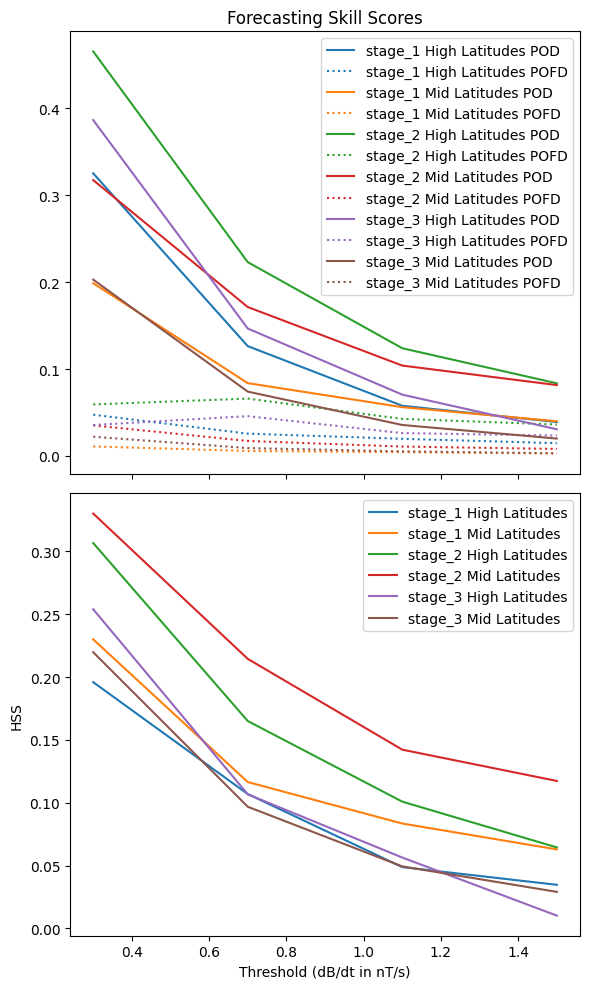

In [55]:
# plot all the skill scores on different plots
fig, axs = plt.subplots(2, 1, figsize=(6, 10), sharex=True)

axs[0].title.set_text("Forecasting Skill Scores")

for i, ss in enumerate(skill_scores.keys()):
    axs[0].plot(
        thres,
        skill_scores[ss][0],
        color="C" + str(2 * i),
        label=ss + " High Latitudes POD",
    )
    axs[0].plot(
        thres,
        skill_scores[ss][1],
        color="C" + str(2 * i),
        linestyle=":",
        label=ss + " High Latitudes POFD",
    )
    axs[0].plot(
        thres,
        skill_scores[ss][3],
        color="C" + str(2 * i + 1),
        label=ss + " Mid Latitudes POD",
    )
    axs[0].plot(
        thres,
        skill_scores[ss][4],
        color="C" + str(2 * i + 1),
        linestyle=":",
        label=ss + " Mid Latitudes POFD",
    )
    axs[0].legend()

    axs[1].plot(
        thres, skill_scores[ss][2], color="C" + str(2 * i), label=ss + " High Latitudes"
    )
    axs[1].plot(
        thres,
        skill_scores[ss][5],
        color="C" + str(2 * i + 1),
        label=ss + " Mid Latitudes",
    )
    axs[1].set_ylabel("HSS")
    axs[1].legend()

axs[1].set_xlabel("Threshold (dB/dt in nT/s)")

plt.tight_layout()

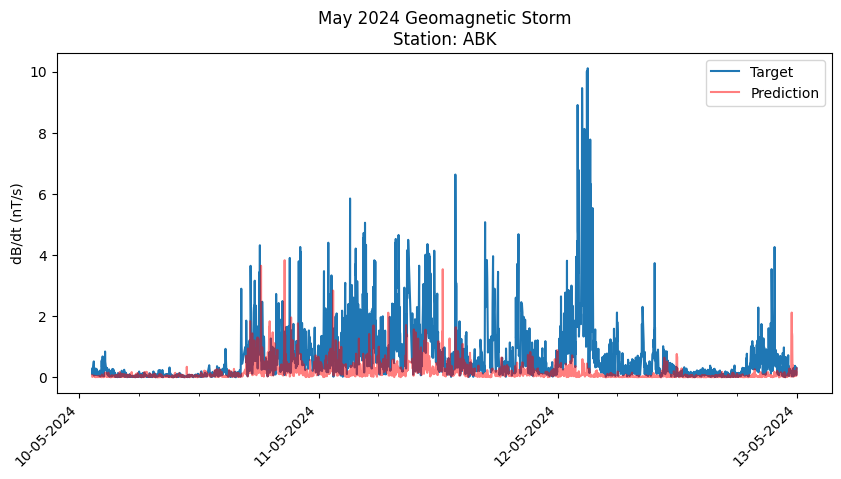

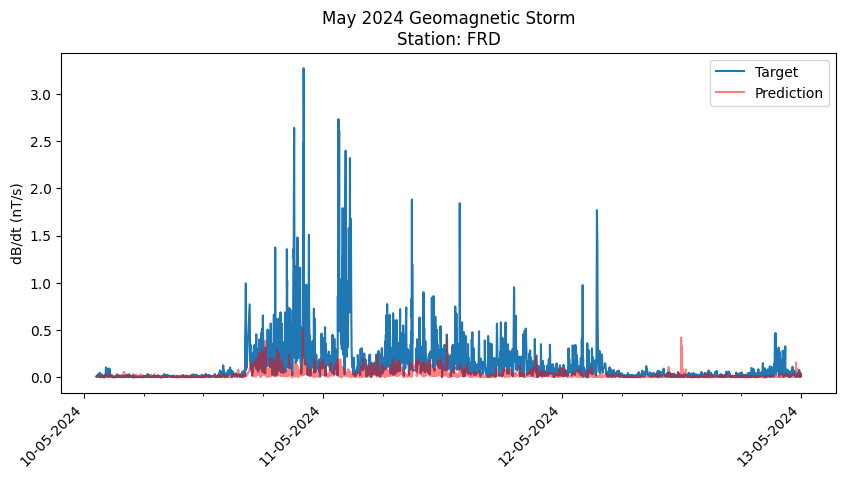

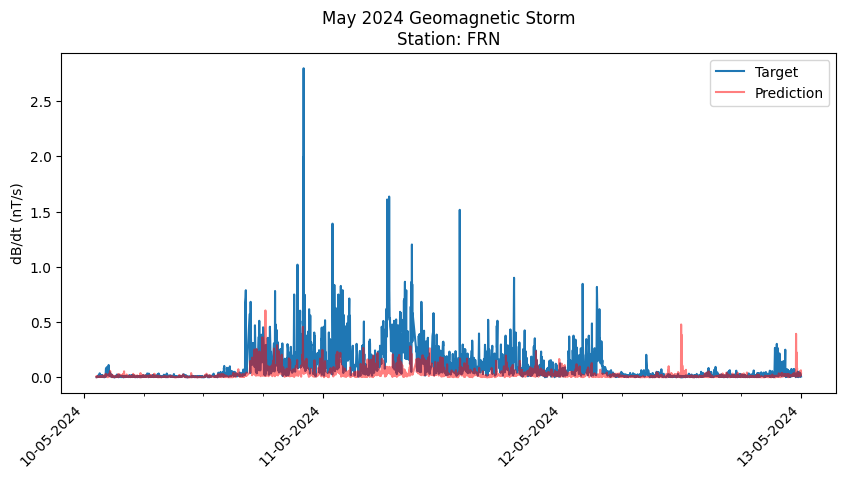

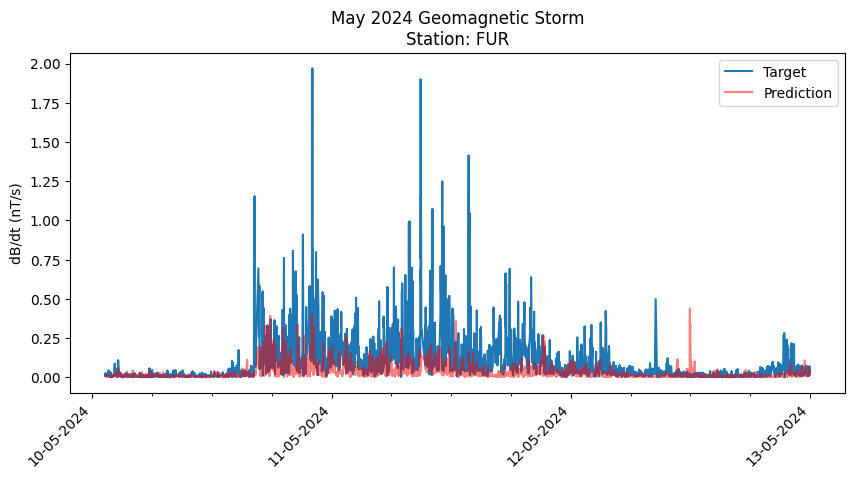

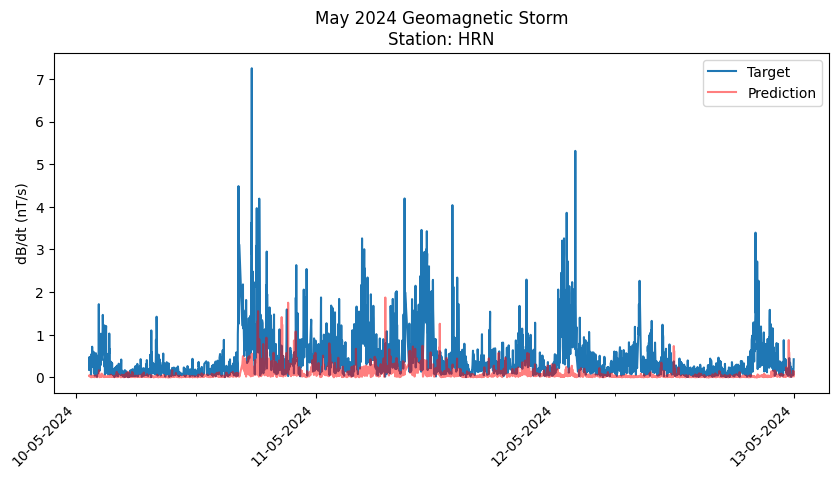

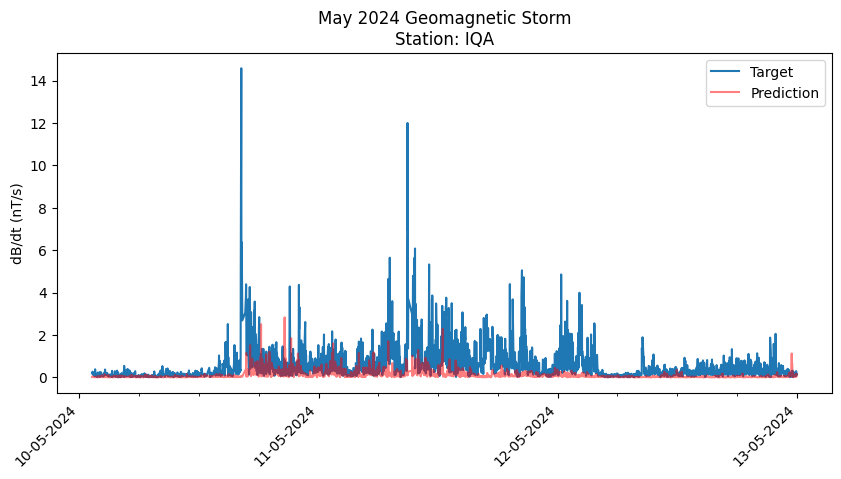

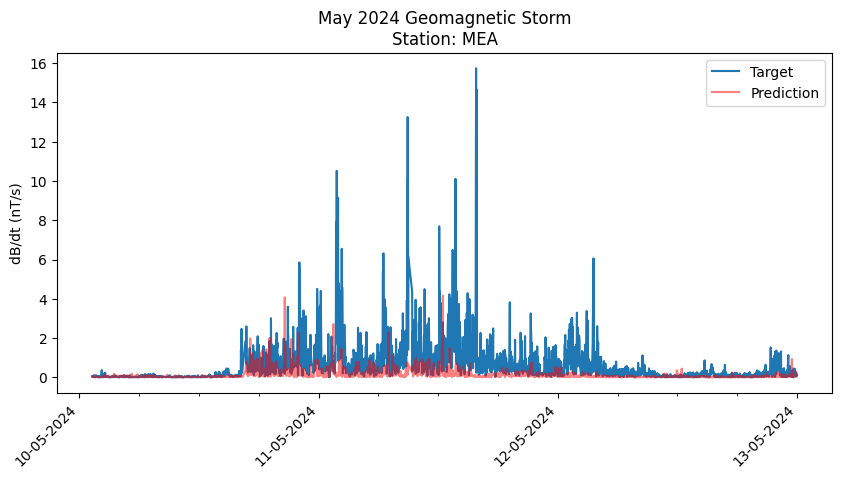

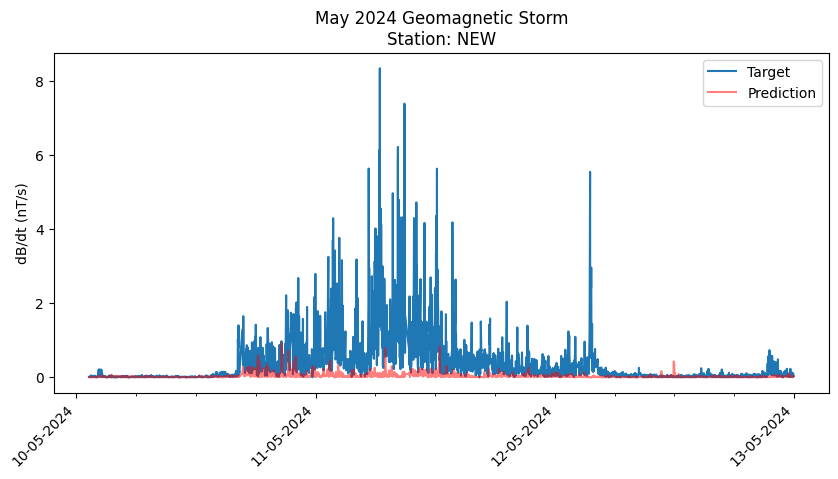

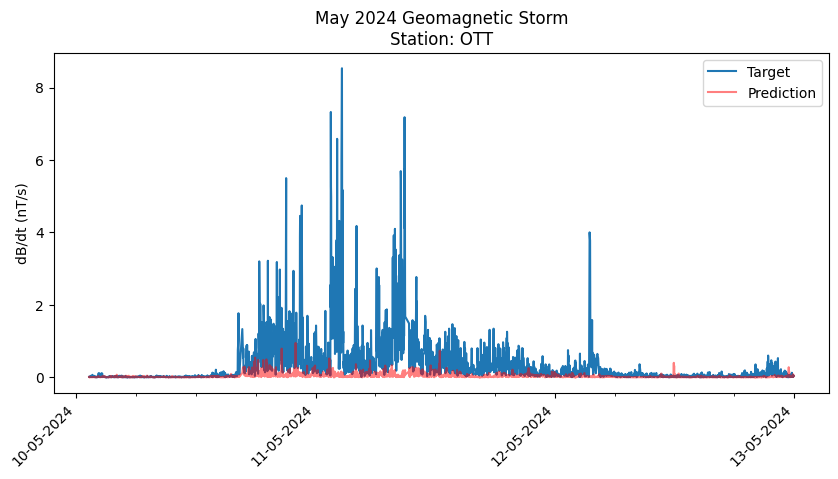

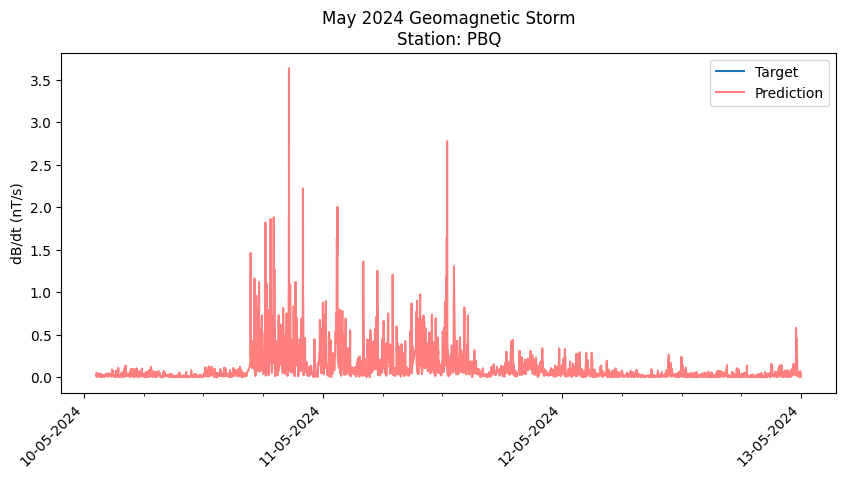

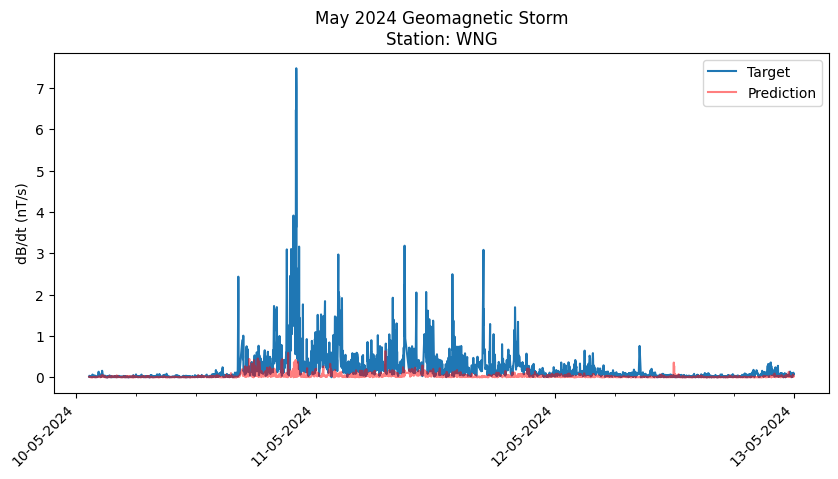

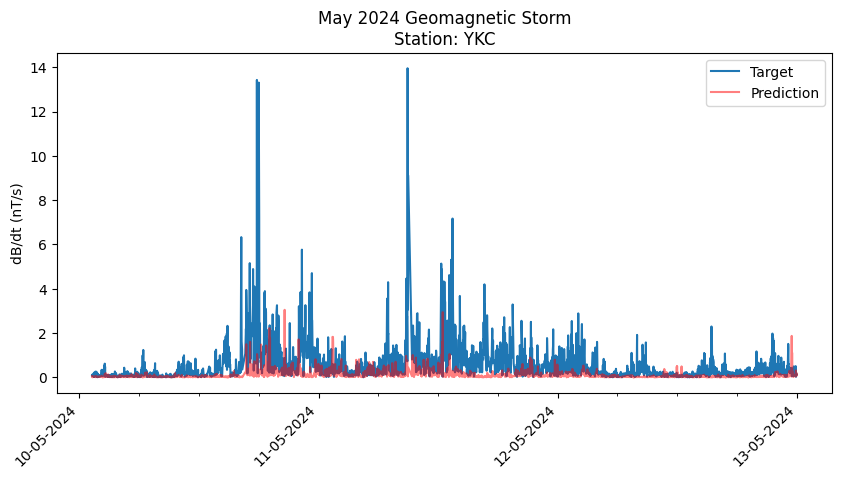

In [56]:
sca = 1.0
for i in stn_subset["stns"]:
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    db_df_target[i].loc[benchmark_events[-1][0] : benchmark_events[-1][1]].plot(
        ax=ax, label="Target"
    )
    (db_df[i].loc[benchmark_events[-1][0] : benchmark_events[-1][1]] * sca).plot(
        color="r", alpha=0.5, ax=ax, label="Prediction"
    )
    plt.legend()
    plt.title("May 2024 Geomagnetic Storm\nStation: " + i)
    plt.ylabel("dB/dt (nT/s)")
    plt.gca().xaxis.set_minor_locator(mdates.HourLocator(byhour=range(0, 24, 6)))
    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
    # set day, month in abbreviated form and year
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%Y"))
    plt.xticks(rotation=45)